# EqualAreasFilter — online / real-time EDP

Recursive equal-areas estimator with NIS drift detection. Ingests one sample
at a time (`partial_fit`) with bounded per-update cost and tracks
time-varying parameters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import dtfit as dt

## Stream — sine whose amplitude jumps 3 → 6 (concept drift)

In [2]:
n = 1500
t = np.linspace(0, 30, n)
A_true = np.where(t < 15, 3.0, 6.0)  # sharp upward jump
rng = np.random.default_rng(0)
y = A_true * np.sin(1.5 * t) + rng.normal(0, 0.5, n)

## Run the filter sample-by-sample

The NIS detector resets the filter on a statistically sharp innovation, so it
re-adapts quickly after the jump. (A slow *downward* drift is the harder case
and would want a CUSUM-style detector — try editing `A_true` to explore.)

In [3]:
flt = dt.EqualAreasFilter(
    "A*sin(w*t)", "t", p0=[2.0, 1.5], window_size=50,
    q_diag=[0.1, 0.0005], r=10.0,
)

A_hist, w_hist = [], []
for ti, yi in zip(t, y):
    p = flt.partial_fit(ti, yi).params_
    A_hist.append(p["A"]); w_hist.append(p["w"])

print("final params:", flt.params_)

final params: {'A': 5.893187021291401, 'w': 1.4997618408527678}


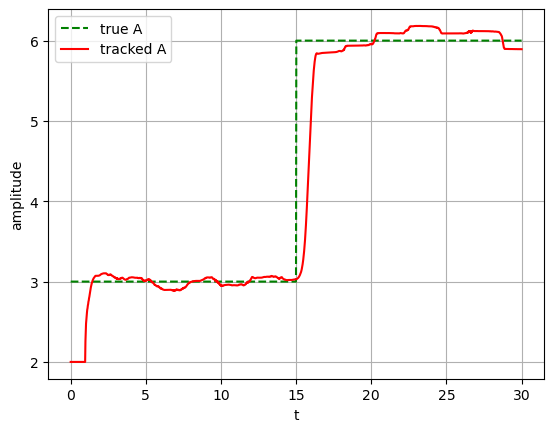

In [4]:
plt.plot(t, A_true, "g--", label="true A")
plt.plot(t, A_hist, "r-", label="tracked A")
plt.xlabel("t"); plt.ylabel("amplitude"); plt.legend(); plt.grid(True); plt.show()